# Introduction

Do higher film budgets lead to more box office revenue? Let's find out if there's a relationship using the movie budgets and financial performance data that I've scraped from [the-numbers.com](https://www.the-numbers.com/movie/budgets) on **May 1st, 2018**. 

<img src=https://i.imgur.com/kq7hrEh.png>

# Import Statements

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Notebook Presentation

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Read the Data

In [3]:
data = pd.read_csv('cost_revenue_dirty.csv')


# Explore and Clean the Data

**Challenge**: Answer these questions about the dataset:
1. How many rows and columns does the dataset contain?
2. Are there any NaN values present?
3. Are there any duplicate rows?
4. What are the data types of the columns?

In [4]:
print(data.shape)
print(f"The NaN : \n{data.isna().sum()}")
print(f"Is there duplicate? : {data.duplicated().sum()}")
print(f"Data types : {data.info()}")
print(data.head(5))

(5391, 6)
The NaN : 
Rank                     0
Release_Date             0
Movie_Title              0
USD_Production_Budget    0
USD_Worldwide_Gross      0
USD_Domestic_Gross       0
dtype: int64
Is there duplicate? : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Rank                   5391 non-null   int64 
 1   Release_Date           5391 non-null   object
 2   Movie_Title            5391 non-null   object
 3   USD_Production_Budget  5391 non-null   object
 4   USD_Worldwide_Gross    5391 non-null   object
 5   USD_Domestic_Gross     5391 non-null   object
dtypes: int64(1), object(5)
memory usage: 252.8+ KB
Data types : None
   Rank Release_Date                     Movie_Title USD_Production_Budget  \
0  5293     8/2/1915           The Birth of a Nation              $110,000   
1  5140     5/9/1916                    

### Data Type Conversions

**Challenge**: Convert the `USD_Production_Budget`, `USD_Worldwide_Gross`, and `USD_Domestic_Gross` columns to a numeric format by removing `$` signs and `,`. 
<br>
<br>
Note that *domestic* in this context refers to the United States.

In [5]:
# Cleaning USD Production Budget
data.USD_Production_Budget = data.USD_Production_Budget.astype(str).str.replace("$", "", regex=False)
data.USD_Production_Budget = data.USD_Production_Budget.astype(str).str.replace(",", "", regex=False)
data.USD_Production_Budget = pd.to_numeric(data.USD_Production_Budget)
# Cleaning USD worldwide Gross
data.USD_Worldwide_Gross = data.USD_Worldwide_Gross.astype(str).str.replace("$", "", regex=False)
data.USD_Worldwide_Gross = data.USD_Worldwide_Gross.astype(str).str.replace(",", "", regex=False)
data.USD_Worldwide_Gross = pd.to_numeric(data.USD_Worldwide_Gross)
# Cleaning USD_Domestic_Gross
data.USD_Domestic_Gross = data.USD_Domestic_Gross.astype(str).str.replace("$", "", regex=False)
data.USD_Domestic_Gross = data.USD_Domestic_Gross.astype(str).str.replace(",", "", regex=False)
data.USD_Domestic_Gross = pd.to_numeric(data.USD_Domestic_Gross)
print(data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Rank                   5391 non-null   int64 
 1   Release_Date           5391 non-null   object
 2   Movie_Title            5391 non-null   object
 3   USD_Production_Budget  5391 non-null   int64 
 4   USD_Worldwide_Gross    5391 non-null   int64 
 5   USD_Domestic_Gross     5391 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 252.8+ KB
None


**Challenge**: Convert the `Release_Date` column to a Pandas Datetime type. 

In [6]:
data.Release_Date = pd.to_datetime(data.Release_Date)
print(data.Release_Date.dtype)
print(data.head(5))

datetime64[ns]
   Rank Release_Date                     Movie_Title  USD_Production_Budget  \
0  5293   1915-08-02           The Birth of a Nation                 110000   
1  5140   1916-05-09                     Intolerance                 385907   
2  5230   1916-12-24    20,000 Leagues Under the Sea                 200000   
3  5299   1920-09-17  Over the Hill to the Poorhouse                 100000   
4  5222   1925-01-01                  The Big Parade                 245000   

   USD_Worldwide_Gross  USD_Domestic_Gross  
0             11000000            10000000  
1                    0                   0  
2              8000000             8000000  
3              3000000             3000000  
4             22000000            11000000  


### Descriptive Statistics

**Challenge**: 

1. What is the average production budget of the films in the data set?
2. What is the average worldwide gross revenue of films?
3. What were the minimums for worldwide and domestic revenue?
4. Are the bottom 25% of films actually profitable or do they lose money?
5. What are the highest production budget and highest worldwide gross revenue of any film?
6. How much revenue did the lowest and highest budget films make?

In [7]:
avg_budget = data.USD_Production_Budget.mean()
print(f"🧮 Average production budget is ${avg_budget:,.2f}")
avg_world_gross = data.USD_Worldwide_Gross.mean()
print(f"🧮 Average Worldwide Gross is ${avg_world_gross:,.2f}")
minimum_worldwide = data.USD_Worldwide_Gross.min()
print(f"🧮 Minimum Revenue Worldwide is ${minimum_worldwide:,.2f}")
minimum_domestic = data.USD_Domestic_Gross.min()
print(f"🧮 Minimum Revenue Domestic is ${minimum_domestic:,.2f}")
# Answering this question : Are the bottom 25% of films actually profitable or do they lose money?
budget_stats = data.USD_Production_Budget.describe()
budget_25_percent = budget_stats['25%']
print(budget_25_percent)
low_budget_movies = data[data.USD_Production_Budget <= budget_25_percent]
avg_budget = low_budget_movies.USD_Production_Budget.mean()
avg_revenue = low_budget_movies.USD_Worldwide_Gross.mean()
profitability = avg_revenue - avg_budget

print(f"🧮 Average Budget: ${avg_budget:,.2f}")
print(f"💰 Average Revenue: ${avg_revenue:,.2f}")
print(f"📈 Profit Margin: ${profitability:,.2f}")
# Answering this question : What are the highest production budget and highest worldwide gross revenue of any film?
highest_budget = data.USD_Production_Budget.max()
print(f"Highest Budget: ${highest_budget:,.2f}")
highest_ww_revenue = data.USD_Worldwide_Gross.max()
print(f"Highest World Wide Revenue: ${highest_ww_revenue:,.2f}")
# Answering this question : How much revenue did the lowest and highest budget films make?
lowest_budget = data[data.USD_Production_Budget == data.USD_Production_Budget.min()]
low_revenue = lowest_budget.USD_Worldwide_Gross.values[0]

highest_budget = data[data.USD_Production_Budget == data.USD_Production_Budget.max()]
high_revenue = highest_budget.USD_Worldwide_Gross.values[0]

print(f"💸 Revenue of the lowest budget film: ${low_revenue:,.2f}")
print(f"💰 Revenue of the highest budget film: ${high_revenue:,.2f}")

🧮 Average production budget is $31,113,737.58
🧮 Average Worldwide Gross is $88,855,421.96
🧮 Minimum Revenue Worldwide is $0.00
🧮 Minimum Revenue Domestic is $0.00
5000000.0
🧮 Average Budget: $2,071,709.29
💰 Average Revenue: $11,493,869.08
📈 Profit Margin: $9,422,159.79
Highest Budget: $425,000,000.00
Highest World Wide Revenue: $2,783,918,982.00
💸 Revenue of the lowest budget film: $181,041.00
💰 Revenue of the highest budget film: $2,783,918,982.00


# Investigating the Zero Revenue Films

**Challenge** How many films grossed $0 domestically (i.e., in the United States)? What were the highest budget films that grossed nothing?

In [8]:
zero_gross_revenue = data[data.USD_Domestic_Gross == 0]
print(f"🎬 Number of films with $0 domestic gross: {zero_gross_revenue.shape[0]}")
zero_gross_revenue.sort_values('USD_Production_Budget', ascending=False)


🎬 Number of films with $0 domestic gross: 512


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,175000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5090,556,2015-12-31,"Don Gato, el inicio de la pandilla",80000000,4547660,0
...,...,...,...,...,...,...
4787,5371,2014-12-31,Stories of Our Lives,15000,0,0
3056,5374,2007-12-31,Tin Can Man,12000,0,0
4907,5381,2015-05-19,Family Motocross,10000,0,0
5006,5389,2015-09-29,Signed Sealed Delivered,5000,0,0


**Challenge**: How many films grossed $0 worldwide? What are the highest budget films that had no revenue internationally?

In [9]:
zero_gross_ww_revenue = data[data.USD_Worldwide_Gross == 0]
print(f"🎬 Number of films with $0 Worldwide gross: {zero_gross_ww_revenue.shape[0]}")
zero_gross_ww_revenue.sort_values('USD_Production_Budget', ascending=False)

🎬 Number of films with $0 Worldwide gross: 357


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,175000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5058,880,2015-11-12,The Ridiculous 6,60000000,0,0
...,...,...,...,...,...,...
4787,5371,2014-12-31,Stories of Our Lives,15000,0,0
3056,5374,2007-12-31,Tin Can Man,12000,0,0
4907,5381,2015-05-19,Family Motocross,10000,0,0
5006,5389,2015-09-29,Signed Sealed Delivered,5000,0,0


### Filtering on Multiple Conditions

In [10]:
international_releases = data.loc[(data.USD_Domestic_Gross == 0) & 
                                  (data.USD_Worldwide_Gross != 0)]
print(international_releases.shape[0])

155


**Challenge**: Use the [`.query()` function](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.query.html) to accomplish the same thing. Create a subset for international releases that had some worldwide gross revenue, but made zero revenue in the United States. 

Hint: This time you'll have to use the `and` keyword.

In [11]:
international_releases = data.query('USD_Domestic_Gross == 0 and USD_Worldwide_Gross != 0')
print(f"Number of International releases: {len(international_releases)}")

Number of International releases: 155


### Unreleased Films

**Challenge**:
* Identify which films were not released yet as of the time of data collection (May 1st, 2018).
* How many films are included in the dataset that have not yet had a chance to be screened in the box office? 
* Create another DataFrame called data_clean that does not include these films. 

In [12]:
# Date of Data Collection
scrape_date = pd.Timestamp('2018-5-1')
not_released_films = data[data.Release_Date >= scrape_date]
print(not_released_films.sort_values('Release_Date', ascending=False))
print(f"Number of movies not screened yet: {len(not_released_films)}")
clean_data = data[data.Release_Date < scrape_date]
print(clean_data.head(5))

      Rank Release_Date                     Movie_Title  \
5388    96   2020-12-31                     Singularity   
5389  1119   2020-12-31          Hannibal the Conqueror   
5390  2517   2020-12-31  Story of Bonnie and Clyde, The   
5387   126   2018-12-18                         Aquaman   
5385   366   2018-10-08                  Amusement Park   
5386  2950   2018-10-08                             Meg   
5384   321   2018-09-03               A Wrinkle in Time   

      USD_Production_Budget  USD_Worldwide_Gross  USD_Domestic_Gross  
5388              175000000                    0                   0  
5389               50000000                    0                   0  
5390               20000000                    0                   0  
5387              160000000                    0                   0  
5385              100000000                    0                   0  
5386               15000000                    0                   0  
5384              103000000   

### Films that Lost Money

**Challenge**: 
What is the percentage of films where the production costs exceeded the worldwide gross revenue? 

In [13]:
money_losing = clean_data[clean_data.USD_Production_Budget > clean_data.USD_Worldwide_Gross]
loss_percentage = (len(money_losing) / len(clean_data)) * 100
print(f"📉 Percentage of films that lost money: {loss_percentage:.2f}%")

print(loss_percentage)

📉 Percentage of films that lost money: 37.28%
37.27711738484398


# Seaborn for Data Viz: Bubble Charts

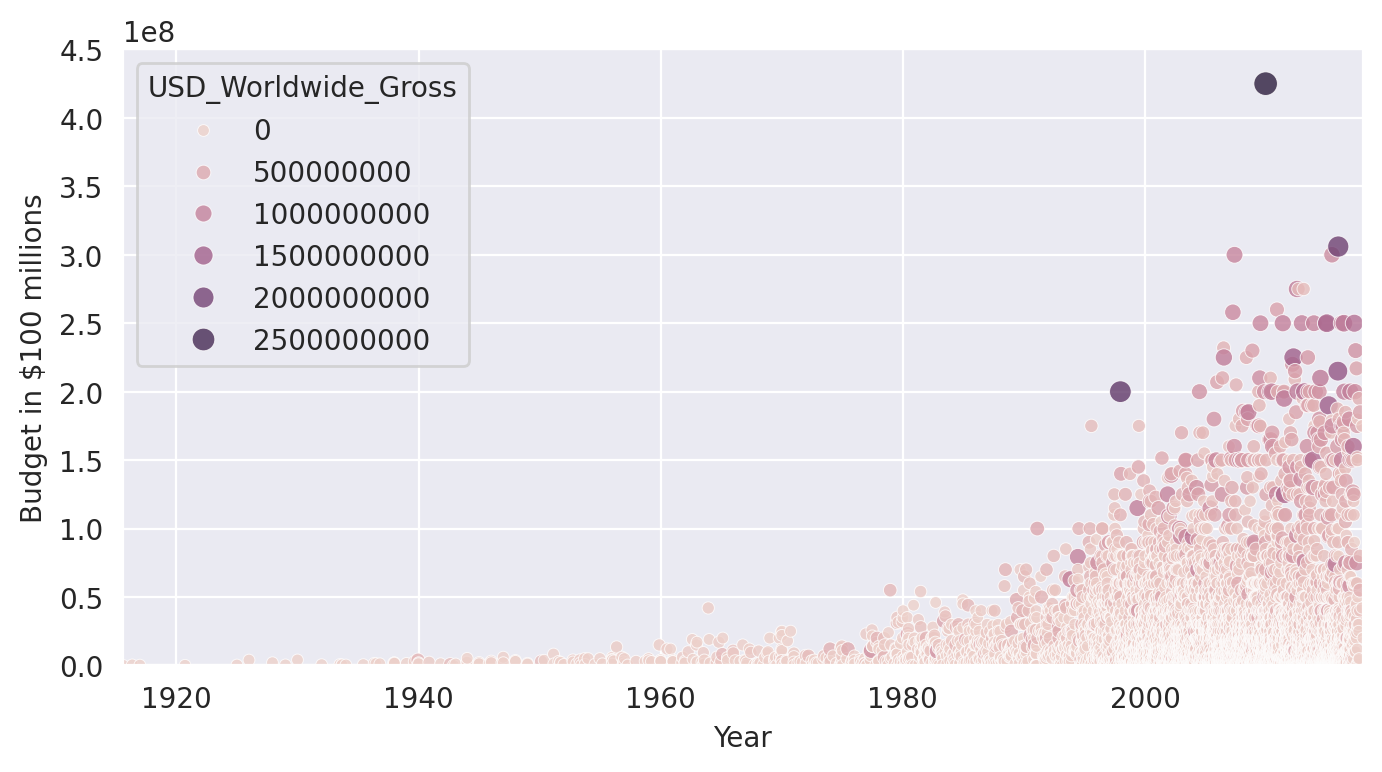

In [14]:
plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style('darkgrid'):
  ax = sns.scatterplot(data=clean_data, x='Release_Date', y='USD_Production_Budget', size='USD_Worldwide_Gross', hue='USD_Worldwide_Gross', alpha=0.8)
  ax.set(ylim=(0, 450000000),
           xlim=(clean_data.Release_Date.min(), clean_data.Release_Date.max()),
           xlabel='Year',
           ylabel='Budget in $100 millions')

### Plotting Movie Releases over Time

**Challenge**: Try to create the following Bubble Chart:

<img src=https://i.imgur.com/8fUn9T6.png>



# Converting Years to Decades Trick

**Challenge**: Create a column in `data_clean` that has the decade of the release. 

<img src=https://i.imgur.com/0VEfagw.png width=650> 

Here's how: 
1. Create a [`DatetimeIndex` object](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DatetimeIndex.html) from the Release_Date column. 
2. Grab all the years from the `DatetimeIndex` object using the `.year` property.
<img src=https://i.imgur.com/5m06Ach.png width=650>
3. Use floor division `//` to convert the year data to the decades of the films.
4. Add the decades as a `Decade` column to the `data_clean` DataFrame.

In [15]:
release_years = clean_data.Release_Date.dt.year
decades = (release_years // 10) * 10
clean_data['Decade'] = decades
print(clean_data.head(5))

   Rank Release_Date                     Movie_Title  USD_Production_Budget  \
0  5293   1915-08-02           The Birth of a Nation                 110000   
1  5140   1916-05-09                     Intolerance                 385907   
2  5230   1916-12-24    20,000 Leagues Under the Sea                 200000   
3  5299   1920-09-17  Over the Hill to the Poorhouse                 100000   
4  5222   1925-01-01                  The Big Parade                 245000   

   USD_Worldwide_Gross  USD_Domestic_Gross  Decade  
0             11000000            10000000    1910  
1                    0                   0    1910  
2              8000000             8000000    1910  
3              3000000             3000000    1920  
4             22000000            11000000    1920  


/tmp/ipykernel_12566/2773801714.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['Decade'] = decades


### Separate the "old" (before 1969) and "New" (1970s onwards) Films

**Challenge**: Create two new DataFrames: `old_films` and `new_films`
* `old_films` should include all the films before 1969 (up to and including 1969)
* `new_films` should include all the films from 1970 onwards
* How many films were released prior to 1970?
* What was the most expensive film made prior to 1970?

In [16]:
old_films = clean_data[clean_data.Decade < 1969]
new_films = clean_data[clean_data.Decade >= 1970]
print(f"Number of Movies released prior 1970: {old_films.shape[0]}")
expensive_old_film = old_films.USD_Production_Budget.max()
movie_title = old_films.loc[old_films.USD_Production_Budget == expensive_old_film, 'Movie_Title'].values[0]
print(f"The most expensive movie prior 1970's : {movie_title } ${expensive_old_film:,.2f}")

Number of Movies released prior 1970: 153
The most expensive movie prior 1970's : Cleopatra $42,000,000.00


# Seaborn Regression Plots

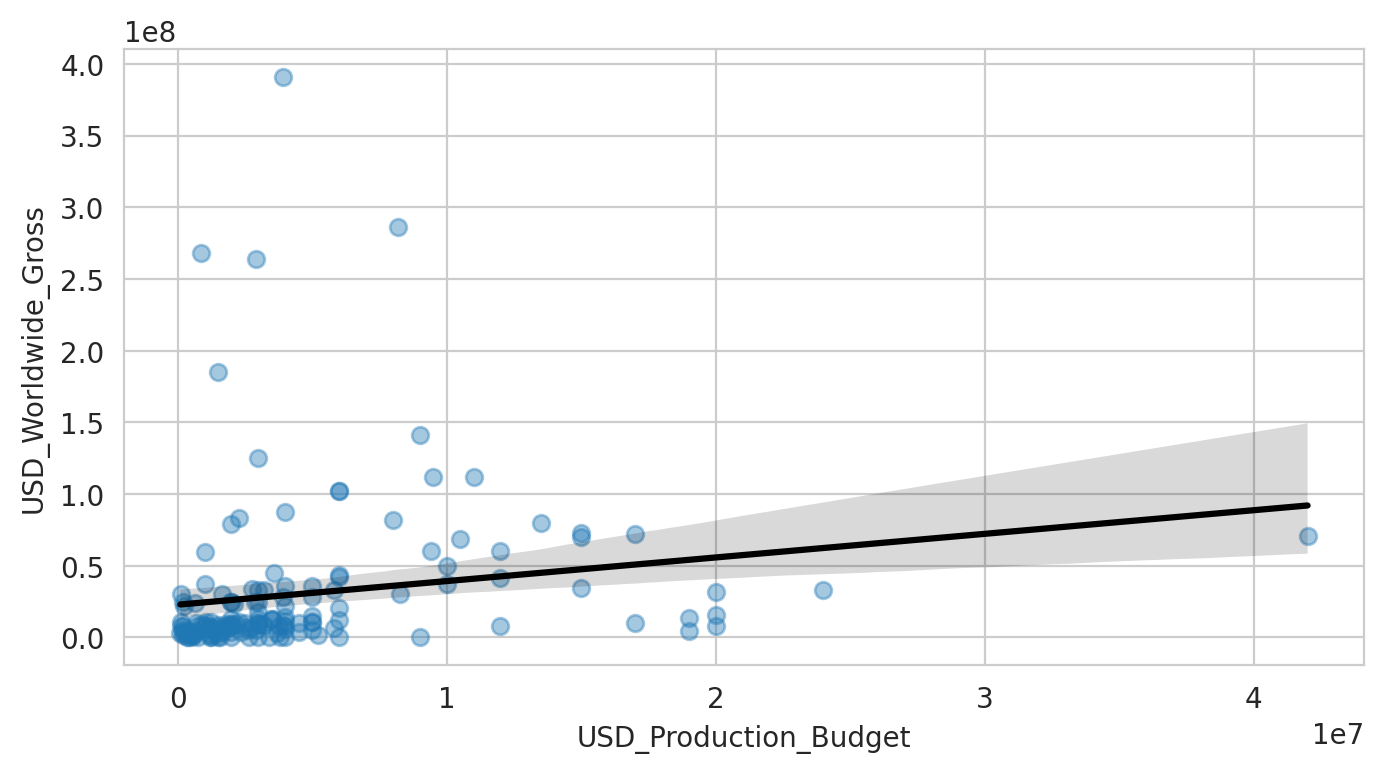

In [17]:

plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style("whitegrid"):
  sns.regplot(data=old_films, 
            x='USD_Production_Budget', 
            y='USD_Worldwide_Gross',
            scatter_kws = {'alpha': 0.4},
            line_kws = {'color': 'black'})

**Challenge**: Use Seaborn's `.regplot()` to show the scatter plot and linear regression line against the `new_films`. 
<br>
<br>
Style the chart

* Put the chart on a `'darkgrid'`.
* Set limits on the axes so that they don't show negative values.
* Label the axes on the plot "Revenue in \$ billions" and "Budget in \$ millions".
* Provide HEX colour codes for the plot and the regression line. Make the dots dark blue (#2f4b7c) and the line orange (#ff7c43).

Interpret the chart

* Do our data points for the new films align better or worse with the linear regression than for our older films?
* Roughly how much would a film with a budget of $150 million make according to the regression line?

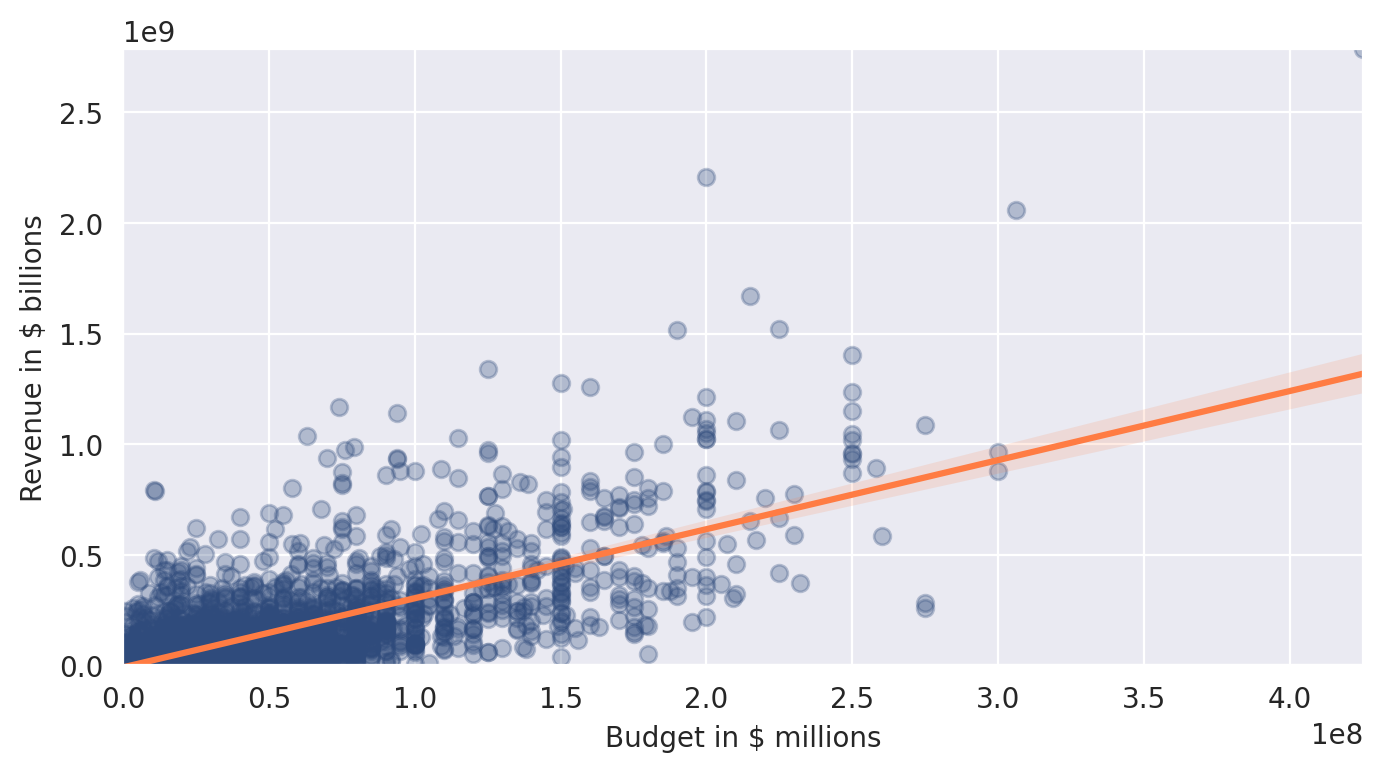

In [ ]:
plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style('darkgrid'):
  ax = sns.regplot(data=new_films, 
            x='USD_Production_Budget',
            y='USD_Worldwide_Gross',
            color='#2f4b7c',
            scatter_kws = {'alpha': 0.3},
            line_kws = {'color': '#ff7c43'})
  ax.set(ylim=(0, new_films.USD_Worldwide_Gross.max()),
      xlim=(0, new_films.USD_Production_Budget.max()),
      xlabel='Budget in $ millions',
      ylabel='Revenue in $ billions'
      )



 

# Run Your Own Regression with scikit-learn

$$ REV \hat ENUE = \theta _0 + \theta _1 BUDGET$$

In [40]:
regression = LinearRegression()
X = pd.DataFrame(new_films, columns=['USD_Production_Budget'])
y = pd.DataFrame(new_films, columns=['USD_Worldwide_Gross'])
regression.fit(X, y)
print(regression.intercept_)
print(regression.coef_)
print(f"r-squared is: {regression.score(X, y)}")
revenue_estimate = regression.predict([[350_000_000]])[0][0]
print(f"Prediction for a movie that costs $350 million: ${revenue_estimate:,.2f}")




[-8650768.00661027]
[[3.12259592]]
r-squared is: 0.5577032617720403
Prediction for a movie that costs $350 million: $1,084,257,803.06


/media/aymen/01D1B91E9241FA90/EDUCATION/Python/001 Seaborn-Linear-Regression-start/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Challenge**: Run a linear regression for the `old_films`. Calculate the intercept, slope and r-squared. How much of the variance in movie revenue does the linear model explain in this case?

In [ ]:
X = pd.DataFrame(old_films, columns=['USD_Production_Budget'])
y = pd.DataFrame(old_films, columns=['USD_Worldwide_Gross'])
regression.fit(X, y)
print(regression.intercept_)
print(regression.coef_)
print(f"r-squared is: {regression.score(X, y)}")


[22821538.63508039]
[[1.64771314]]
r-squared is: 0.02937258620576877
Prediction for a movie that costs $350 million: $600,000,000.00
Prediction for a movie that costs $275 million: $475,942,653.24


/media/aymen/01D1B91E9241FA90/EDUCATION/Python/001 Seaborn-Linear-Regression-start/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/media/aymen/01D1B91E9241FA90/EDUCATION/Python/001 Seaborn-Linear-Regression-start/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Use Your Model to Make a Prediction

We just estimated the slope and intercept! Remember that our Linear Model has the following form:

$$ REV \hat ENUE = \theta _0 + \theta _1 BUDGET$$

**Challenge**:  How much global revenue does our model estimate for a film with a budget of $350 million? 

In [43]:
revenue_estimate = regression.predict([[350_000_000]])[0][0]
revenue_estimate = round(revenue_estimate, -6)
print(f"Prediction for a movie that costs $350 million: ${revenue_estimate:,.2f}")


Prediction for a movie that costs $350 million: $600,000,000.00


/media/aymen/01D1B91E9241FA90/EDUCATION/Python/001 Seaborn-Linear-Regression-start/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
